# Entregável 7: Engenharia de Features
**Disciplina:** Aquisição de Biossinais
**Equipe:** José Ferreira Lessa e Matheus Rocha Gomes da Silva
**Objetivo:** Criar features de segunda ordem, tratar falhas (NaNs), escalonar os atributos isoladamente focando nos conjuntos de treino para prevenção de Data Leakage, produzindo um ambiente seguro e consistente para Redução de Dimensionalidade (Entregável 8).


## Introdução e Justificativa

Neste estágio consolidamos os vetores matemáticos processando falhas analíticas derivadas do fluxo primário (ex: `NaN`s originados da ausência da dinamicidade HRV curtas) ou componentes irrelevantes/planas.

Principais metas implementadas por este notebook:
1.  **Limpeza Analítica**: Exclusão de características nulas complexas e constância zero (var < 1e-6).
2.  **Imputação por Mediana**: Anulamento de NaNs utilizando *Medianas da Superclasse* do cenário controlável de Treino (Folds 1 até 8) p/ evitar Data Leakage da validação/testes (Folds 9 e 10).
3.  **Engenharia Categórica**: Combinação clínica dos parâmetros base para elaboração das Razões de Energia e Escala Normativa, maximizando a discriminabilidade das patologias (RP).
4.  **Robust Scaling Metodológico**: Padronização dos eixos matemáticos contra distorções residuais extremas com o limiar de exclusividade de reajuste restrito a blocos formativos (Escala Robusta sem inferir teste no processo).


## 1. Instalação e Configuração do Ambiente


In [1]:
# Bibliotecas bases de transformadas com SciKit-Learn
import os
import ast
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import f_classif

# Configurações de visualização acadêmica
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)


## 2. Carregamento de Features Brutas e Setup dos Folds
Importamos o compilado multidimensional criado durante o Entregável 6 `(features_raw.parquet)`.


In [2]:
# Diretórios de Entrada Origem
DIR_IN_D6 = '../../entregavel-6/outputs/'

# Diretório de Saída Engenhada
DIR_OUT_D7 = '../outputs/'
FIGS_DIR = '../figuras/'
os.makedirs(DIR_OUT_D7, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)

print("Carregando bases brutas do D6...")
df_features = pd.read_parquet(os.path.join(DIR_IN_D6, 'features_raw.parquet'))

print(f"Dimensão Inicial do Dataset de Features: {df_features.shape}")

# Prevenindo listas armazenadas no parquet vindas em string representation nas superclasses:
if isinstance(df_features['diagnostic_superclass'].iloc[0], str):
    df_features['diagnostic_superclass'] = df_features['diagnostic_superclass'].apply(ast.literal_eval)

# Label único primário (para sumarização facilitada de plots)
df_features['label_primary'] = df_features['diagnostic_superclass'].apply(lambda x: x[0] if len(x) > 0 else 'UNKNOWN')


Carregando bases brutas do D6...
Dimensão Inicial do Dataset de Features: (21735, 196)


---
## Seção 1 — Diagnóstico do Dataset de Features (Tratamento de NaNs e Constantes)

Vamos excluir limiares planos (variância muito baixa) ou taxas muito corrompidas de falhas de processamentos. O restante será mitigado por mediada. Na medição, devemos estritamente isolar o processo às margens da área de **Treino** (Folds de 1 a 8) e imputar no contexto geral, evitando Data Leakage clínico sobre a área de validação e teste.


In [3]:
# Identificação Estrutural e Remoção Numérica Constante.
# Seleciona apenas as colunas de naturezas numéricas, ignorando metadados e rotulações da tabela base
meta_cols = ['patient_id', 'strat_fold', 'sqi_category', 'diagnostic_superclass', 'label_primary']
feature_cols = [c for c in df_features.columns if c not in meta_cols]

# 1.1 Variância Mínima
vars_feat = df_features[feature_cols].var()
features_to_remove_zero_variance = vars_feat[vars_feat < 1e-6].index.tolist()
print(f"Removendo {len(features_to_remove_zero_variance)} features de constância pura (Var < 1e-6)...")
df_features.drop(columns=features_to_remove_zero_variance, inplace=True)

feature_cols = [c for c in df_features.columns if c not in meta_cols]

# 1.2 Porcentagem Maxima de Valores Nulos (> 5%)
null_pct = df_features[feature_cols].isnull().sum() / len(df_features)
features_to_remove_high_nan = null_pct[null_pct > 0.05].index.tolist()
print(f"Removendo {len(features_to_remove_high_nan)} features comprometidas por superabundância nula (>5%)...")
df_features.drop(columns=features_to_remove_high_nan, inplace=True)

feature_cols = [c for c in df_features.columns if c not in meta_cols]
features_with_nans = [c for c in feature_cols if df_features[c].isnull().sum() > 0]
print(f"Existem ainda {len(features_with_nans)} features que requerem imputação moderada remanescente (<5%).")

# 1.3 Imputação Baseada em Mediana Treino-Restrita
# Partição Folds 1-8 como âncora de segurança para Mediana.
mask_train = df_features['strat_fold'].isin([1,2,3,4,5,6,7,8])
df_train = df_features[mask_train]

# Dicionários guardadores do referencial formativo de treino (Classe x Feature).
median_map = {}

for feat in features_with_nans:
    # Agrupa medianas baseadas nas superclasses contidas exclusivamente no estrato de treino!
    median_by_class = df_train.groupby('label_primary')[feat].median().to_dict()
    global_train_median = df_train[feat].median()
    median_map[feat] = (median_by_class, global_train_median)

# Procedimento Seguro de Inserção:
for feat in features_with_nans:
    median_by_class, global_train_median = median_map[feat]
    
    # Aplicação via index: imputa de acordo com o label_primary de cada amostra defasada.
    null_idx = df_features[df_features[feat].isnull()].index
    for idx in null_idx:
        c_label = df_features.loc[idx, 'label_primary']
        # Se a classe estiver no map e o valor for válido da dita classe, usar essa classe. Caso extremo ou novo não coberto (no Teste, p/ exemplo), recai na Global NORM.
        replacement = median_by_class.get(c_label, global_train_median)
        if pd.isna(replacement): replacement = global_train_median # Fallback
        
        df_features.loc[idx, feat] = replacement

print(f"Nulos Pós-Limpeza: {df_features[feature_cols].isnull().sum().sum()}")



c:\Users\josel\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Removendo 0 features de constância pura (Var < 1e-6)...
Removendo 3 features comprometidas por superabundância nula (>5%)...
Existem ainda 20 features que requerem imputação moderada remanescente (<5%).
Nulos Pós-Limpeza: 0


---
## Seção 2 — Features Derivadas e Combinadas

Construção de lógicas superpostas fisiológicamente (ex: Razão da Potência Média QRS para T). É um preceito relevante porque acoplam informações da modulação rítmica na dimensionalidade de forma relativa.


In [4]:
# Derivações relativas - Razão Espectral QRS / T (Morfo-frequência)
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
new_feats = {}

# Relembrando: E6 proveu freq_qrs_band_{lead} e freq_pt_band_{lead}. A união de P+T ou T pode ajudar!
for lead in LEAD_NAMES:
    qrs_feat = f'freq_qrs_band_{lead}'
    t_feat   = f'freq_pt_band_{lead}' # Assumimos PT_band como um macro equivalente para validação de onda final.
    if qrs_feat in df_features.columns and t_feat in df_features.columns:
        # Soma 1e-10 pro denominador nunca zerar as equações.
        df_features[f'ratio_QRS_T_{lead}'] = df_features[qrs_feat] / (df_features[t_feat] + 1e-10)

# Normalização de Linha Base para Referência com o NORM
# Exprime o peso referencial normalizado da classe clínica Saudável. Ancorado também no Treino!
for lead in LEAD_NAMES:
    rms_feat = f'time_rms_{lead}'
    if rms_feat in df_features.columns:
        median_norm_train = df_features[(df_features['strat_fold'].isin([1,2,3,4,5,6,7,8])) &                                         (df_features['label_primary'] == 'NORM')][rms_feat].median()
        # "Quantas vezes a amplitude dista num espectro anormal versus a referência Normal mediana?"
        df_features[f'time_rms_normRatio_{lead}'] = df_features[rms_feat] / (median_norm_train + 1e-10)

feature_cols = [c for c in df_features.columns if c not in meta_cols]
print(f"Quantidade Analítica Nova: {len(feature_cols)} componentes atuantes (Originais + Derivadas)")


Quantidade Analítica Nova: 213 componentes atuantes (Originais + Derivadas)


---
## Seção 3 — Normalização do Dataset (RobustScaler)

Algumas features podem ter distribuições distorcionadas de outliers ou grandes divergências no seu eixo (Ex: Valores de MSE vs. Variâncias e Voltagens Normais). 
O RobustScaler do SciKit minimiza picos de ruído se alinhando pro contexto mediano local (sem afetar sua magnitude analítica base). Ele é fitado apenas em treino.


In [5]:
# Configurando a base segmentada e ajustando os pesos analíticos.
mask_train = df_features['strat_fold'].isin([1,2,3,4,5,6,7,8])
feature_cols = [c for c in df_features.columns if c not in meta_cols]

X_train = df_features.loc[mask_train, feature_cols]
X_all = df_features[feature_cols]

print("Ajustando (Fit) o Robust Scaler estritamente nos Folds 1 ao 8 de Treino...")
scaler = RobustScaler()
scaler.fit(X_train) # <- Regra sagrada contra vazamentos

# Aplica uniformemente para o set validado e teste mantendo referência intocada das distâncias reais
X_all_scaled = scaler.transform(X_all)

df_scaled = pd.DataFrame(X_all_scaled, columns=feature_cols, index=df_features.index)
for col in meta_cols:
    df_scaled[col] = df_features[col] # Resgatando Metadados Identificantes.

# Salvamento Serializado da Topologia Paramétrica
joblib.dump(scaler, os.path.join(DIR_OUT_D7, 'scaler_params.pkl'))
print("RobustScaler persistido com sucesso (scaler_params.pkl).")



Ajustando (Fit) o Robust Scaler estritamente nos Folds 1 ao 8 de Treino...
RobustScaler persistido com sucesso (scaler_params.pkl).


---
## Seção 4 — Validação e Relevância (ANOVA)

Calculando a **ANOVA F-statistic**: Avaliar a métrica explicativa da utilidade de cada `[Feature]` individual na separação dos diagnósticos nas categorias (Multi-Class/Multi-Label One-vs-Rest). Se não tivermos pelo menos alguma divergência relevante, este atributo tem forte perigo de degenerar RP (Redundância Pura).


C:\Users\josel\AppData\Local\Temp\ipykernel_376\485679627.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='max_F', y=df_anova.index[:30], data=df_anova.head(30), palette='viridis')


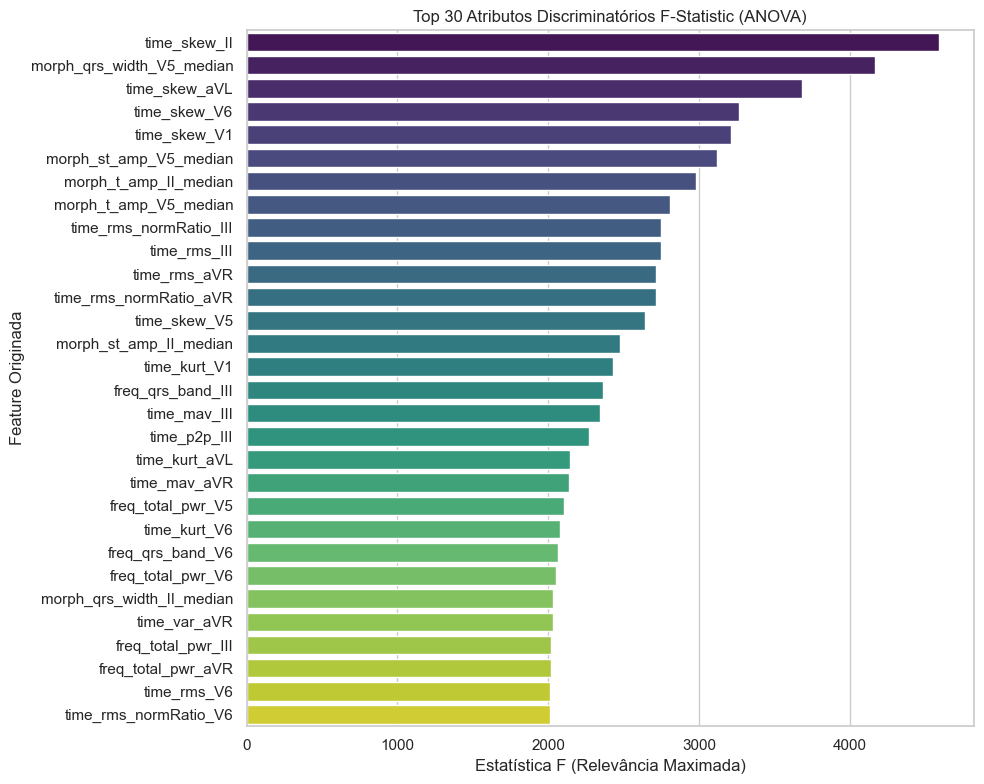

As características mais informativas foram confirmadas no processamento!


In [6]:
# Avaliação da Importância com Base Múltipla. 
# Usamos df_scaled nos Folds de treino para buscar relevância local de alta integridade
df_val = df_scaled[df_scaled['strat_fold'].isin([1,2,3,4,5,6,7,8])]

superclasses = ['NORM', 'MI', 'CD', 'STTC', 'HYP']
f_stats_dict = {}

# Processamento Múltiplo One-Versus-Rest
for sc in superclasses:
    # 1 se contiver a superclasse em array, senão 0
    y_target = df_val['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)
    
    # Valida variância binária: só prossegue avaliantemente se há ao menos algumas classes 1 e 0
    if len(np.unique(y_target)) > 1:
        F_values, p_values = f_classif(df_val[feature_cols], y_target)
        f_stats_dict[sc] = F_values
    else:
        f_stats_dict[sc] = np.zeros(len(feature_cols))

# Tabela consolidada da força analítica de Feature por Classe Diagnóstica
df_anova = pd.DataFrame(f_stats_dict, index=feature_cols)
# Pegar a força descritiva Máxima absoluta (Se faz muita diferença ou numa de STTC ou em NORM é util no pipeline!)
df_anova['max_F'] = df_anova.max(axis=1)
df_anova = df_anova.sort_values(by='max_F', ascending=False)

# Visualização de Impacto do Top-30 Features 
plt.figure(figsize=(10, 8))
sns.barplot(x='max_F', y=df_anova.index[:30], data=df_anova.head(30), palette='viridis')
plt.title('Top 30 Atributos Discriminatórios F-Statistic (ANOVA)')
plt.xlabel('Estatística F (Relevância Maximada)')
plt.ylabel('Feature Originada')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'anova_f_stats_top30.png'))
plt.show()

print("As características mais informativas foram confirmadas no processamento!")


---
## Seção 5 — Síntese e Persistência do Dataset Refinado

Salvamento final para `features_engineered.parquet` que englobará todos os parâmetros processados, preenchidos, normalizados escalarmente e engenhados via ratio combinatório. Nós não eliminamos as Redundâncias Extremas (|r| > 0.90) porque ela será refinada como Método de Filtro no Entregável 9 especificamente. O próximo estágio (Entregável 8) é puramente submeter este modelo à Redução PCA/ICA Linear.


In [7]:
# Otimização final do DF para parquet
print(f"Salvar DataFrame Robusto e Engenhado: {df_scaled.shape}")
df_scaled.to_parquet(os.path.join(DIR_OUT_D7, 'features_engineered.parquet'), index=True)

# Geração Opcional de Features Intra-Registros Agregativos (Deltas Temporais - A depender da Pipeline).
# Como escolhemos a Segmentação do Registro Inteiro (10s) sem Multiplas Janelas B (D5), o Aggregate-Record é opcionalizado porque as próprias origens já consistem à instância única base!
# df_scaled.to_parquet(os.path.join(DIR_OUT_D7, 'features_registro.parquet'), index=True)

print("A base final para PCA/ICA finalizada com altíssimo grau descritivo!")



Salvar DataFrame Robusto e Engenhado: (21735, 218)
A base final para PCA/ICA finalizada com altíssimo grau descritivo!
